In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pingouin as pg
from scipy.stats import shapiro

### Binary data

In [2]:
results_dt = pd.read_csv("../Results/BINARY/similarity_scores_dt_classifier.csv", index_col=0)
results_lr = pd.read_csv("../Results/BINARY/similarity_scores_lr_classifier.csv", index_col=0)
results_unet_binary = pd.read_csv("../Results/BINARY/results_UNET_binary.csv", index_col=0)
results_otsu_equalize = pd.read_csv("../Results/BINARY/similarity_scores_otsu_equalize.csv", index_col=0)
results_watershed = pd.read_csv("../Results/BINARY/similarity_scores_watershed.csv", index_col=0)
results_water_means = pd.read_csv("../Results/BINARY/similarity_scores_water_means.csv", index_col=0)

# Combine results from both models with a model identifier
results_dt_copy = results_dt.copy()
results_dt_copy['Model'] = 'Decision Tree Classifier'
results_unet_binary_copy = results_unet_binary.copy()
results_unet_binary_copy['Model'] = 'UNet Binary'
results_otsu_equalize_copy = results_otsu_equalize.copy()
results_otsu_equalize_copy['Model'] = 'Otsu Equalize'
results_watershed_copy = results_watershed.copy()
results_watershed_copy['Model'] = 'Watershed'
results_water_means_copy = results_water_means.copy()
results_water_means_copy['Model'] = 'Water Means'
results_lr_copy = results_lr.copy()
results_lr_copy['Model'] = 'Logistic Regression'

combined_results = pd.concat([results_unet_binary_copy, results_dt_copy, results_lr_copy, results_water_means_copy, results_watershed_copy, results_otsu_equalize_copy], ignore_index=True)

# One box per model, one pair of boxes per line/dye combination
# Source - https://stackoverflow.com/a/60488299
# Posted by TeArge
# Retrieved 2026-06-06, License - CC BY-SA 4.0

df_binary = pd.melt(combined_results,id_vars=['Model'],
             value_vars=['HT29-dapi','Hs766T-dapi','both-dapi', 'HT29-pi','Hs766T-pi','both-pi'],
             var_name='dye', value_name='similarity_score')

### continuous data

In [4]:
results_dtreg = pd.read_csv("../Results/CONTINUOUS/similarity_scores_dt_regressor.csv", index_col=0)
results_unetreg = pd.read_csv("../Results/CONTINUOUS/results_UNET_cont.csv", index_col=0)

reults_dtreg_copy = results_dtreg.copy()
reults_dtreg_copy['Model'] = 'Decision Tree Regressor'
reults_unetreg_copy = results_unetreg.copy()
reults_unetreg_copy['Model'] = 'UNet Regressor'

combined_results_reg = pd.concat([reults_dtreg_copy, reults_unetreg_copy], ignore_index=True)

df_continuous = pd.melt(combined_results_reg,id_vars=['Model'],
             value_vars=['HT29-dapi','Hs766T-dapi','both-dapi', 'HT29-pi','Hs766T-pi','both-pi'],
             var_name='dye', value_name='similarity_score')


### ANOVA + Box plot comparison

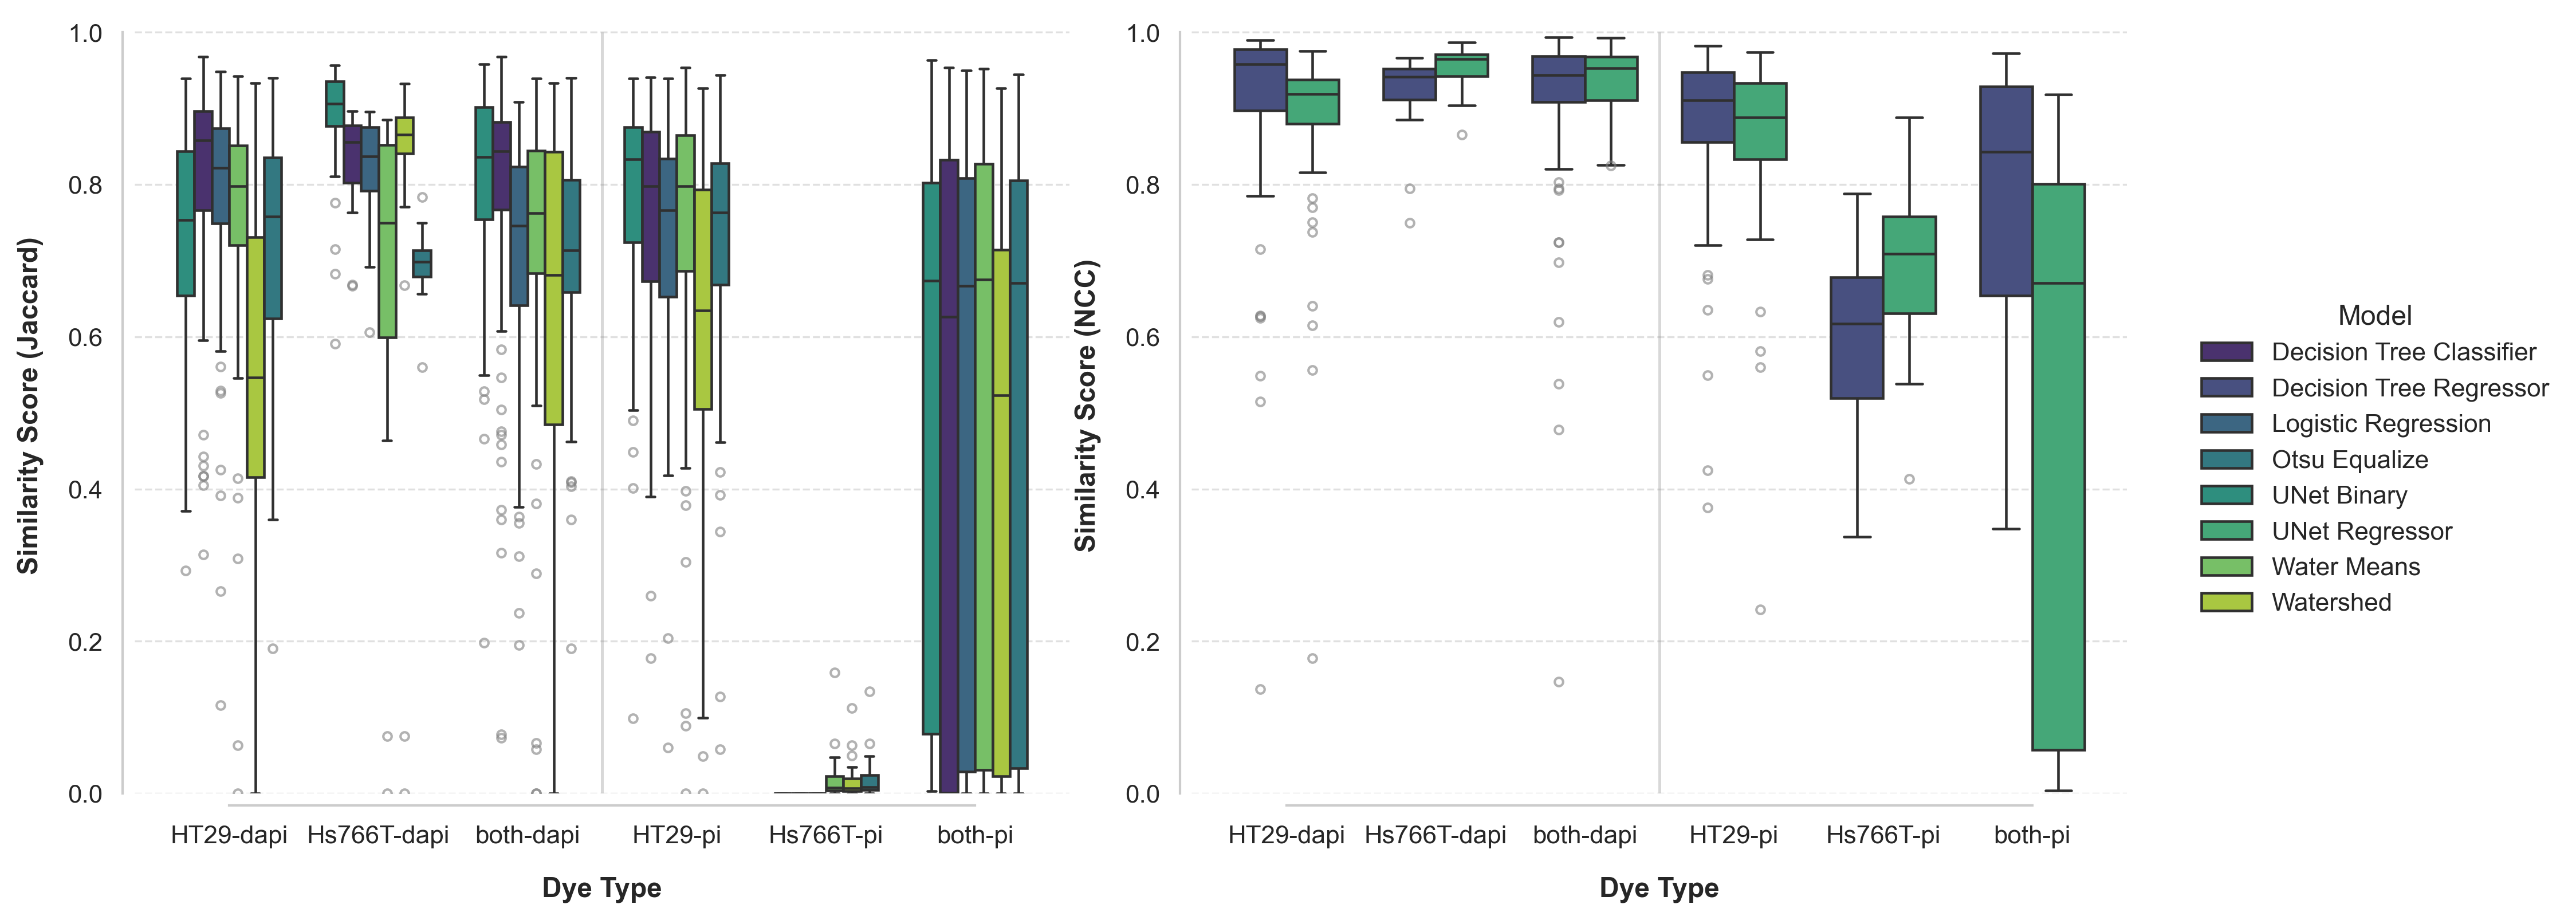

In [4]:
# 1. Set theme and scale up width to comfortably support 6 bars per group
sns.set_theme(style="whitegrid", font="Arial", context="paper", font_scale=1.2)
fig, axs = plt.subplots(1, 2, figsize=(15, 5.5), dpi=300)

# 2. Map colors explicitly to models so colors stay consistent across both plots
all_models = sorted(list(set(df_binary['Model'].unique()) | set(df_continuous['Model'].unique())))
color_palette = sns.color_palette("viridis", len(all_models))
model_colors = dict(zip(all_models, color_palette))


def plot_similarity_scores(df, ax, y_title=None, palette_dict=None):    
    # Plot using our uniform color dictionary
    sns.boxplot(
        data=df, 
        x='dye', 
        y='similarity_score', 
        hue='Model', 
        palette=palette_dict,
        saturation=0.75,      
        width=0.7,  # Marginally wider to handle the high density cleanly          
        linewidth=1.1,        
        fliersize=3.5,          
        flierprops={"markerfacecolor": "none", "markeredgecolor": "gray", "alpha": 0.6},
        ax=ax
    )

    # Clean text formatting
    ax.set_xlabel("Dye Type", fontweight='bold', labelpad=12)
    ax.set_ylabel(y_title, fontweight='bold', labelpad=10)
    ax.set_ylim(0, 1.02)  

    # FIX: Rotate x-axis labels slightly to completely eliminate overlapping text
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')

    # Strip sub-legends during generation so we can draw a master figure-level legend later
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Styling accents
    sns.despine(ax=ax, offset=5, trim=True)
    ax.xaxis.grid(False) 
    ax.yaxis.grid(True, linestyle='--', alpha=0.6) 
    
    # Centered group separator line
    ax.vlines(x=2.5, ymin=0, ymax=1, color='gray', linestyle='-', alpha=0.3)


# 3. Generate individual subplots
plot_similarity_scores(df_binary, axs[0], y_title="Similarity Score (Jaccard)", palette_dict=model_colors)
plot_similarity_scores(df_continuous, axs[1], y_title="Similarity Score (NCC)", palette_dict=model_colors)


# 4. Extract, deduplicate, and assemble a master Figure-Level Legend
handles, labels = [], []
for ax in axs:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

# Sort legend items alphabetically to look intentional and structured
handles, labels = zip(*sorted(zip(handles, labels), key=lambda t: t[1]))

fig.legend(
    handles, labels, 
    title="Model", 
    loc='center left', 
    bbox_to_anchor=(0.85, 0.5),  # Clean placement outside the right subplot margin
    frameon=True,
    facecolor='white',
    edgecolor='none'
)

# 5. Clean layout adjustment to leave clean padding for the right-side legend
plt.tight_layout()
fig.subplots_adjust(right=0.83)


plt.savefig("../Results/similarity_scores_combined.jpeg", dpi=300, bbox_inches='tight')
plt.savefig("../Results/similarity_scores_combined.tiff", dpi=300, bbox_inches='tight')
plt.savefig("../Results/similarity_scores_combined.png", dpi=300, bbox_inches='tight')
plt.show()

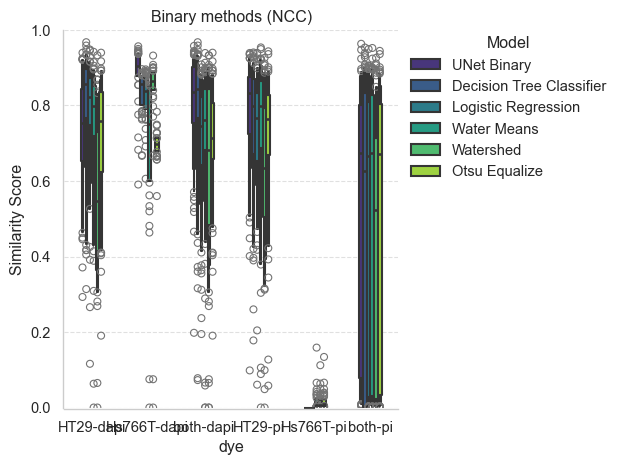

In [5]:
ax = sns.boxenplot(data=df_binary,
            x='dye',
            y='similarity_score',
            hue='Model',
            palette="viridis",
            saturation=0.9,
            width=0.4,
            linewidth=1.5)


plt.legend(
    title="Model", 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0,
    frameon=True,
    facecolor='white',
    edgecolor='none'
)
sns.despine(offset=1, trim=False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6) # Subtle dashed horizontal lines

#plt.axis('off')
plt.ylim(0, 1)
plt.title("Binary methods (NCC)")
plt.ylabel("Similarity Score")
plt.tight_layout()
plt.show()

In [16]:
# Run one-way ANOVA in dataset to compare models
# Test ANOVA de una vía (One-way ANOVA)
# ==============================================================================
anova = pg.anova(data=df, dv='similarity_score', between=['Model', 'dye'], detailed=True)
# T-Test pairwise comparisons with Bonferroni correction to assess specific differences between groups
ttest = pg.pairwise_tests(data=df, dv='similarity_score', between=['Model', 'dye'], padjust='bonf')

# save results to csv
anova.to_csv("../Results/CONTINUOUS/continuous_methods_anova.csv", index=False)
ttest.to_csv("../Results/CONTINUOUS/continuous_methods_pairwise_ttest.csv", index=False)

NameError: name 'df' is not defined

In [42]:
bin_anova = pg.anova(data=df_binary, dv='similarity_score', between=['Model', 'dye'], detailed=True)[['Source','p_unc']].rename(columns={'p_unc': 'p_value_binary'})
cont_anova = pg.anova(data=df_continuous, dv='similarity_score', between=['Model', 'dye'], detailed=True)[['p_unc']].rename(columns={'p_unc': 'p_value_continuous'})

combined_anova = pd.concat([bin_anova, cont_anova], axis=1).drop(index=bin_anova.index[-1])  # Drop the duplicate 'Residual' row
print(combined_anova.to_latex(index=False, float_format="%.2E", column_format='lcc'))

\begin{tabular}{lcc}
\toprule
Source & p_value_binary & p_value_continuous \\
\midrule
Model & 4.09E-13 & 2.26E-07 \\
dye & 3.51E-306 & 3.32E-61 \\
Model * dye & 4.73E-04 & 1.21E-19 \\
\bottomrule
\end{tabular}



### Visualizing Data distribution

Text(0.5, 1.0, 'Distribution of Similarity Scores (Jaccard)')

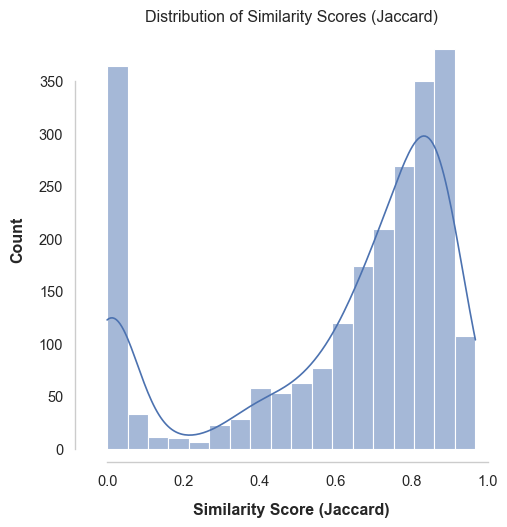

In [157]:
ax = sns.displot(df_binary,
                x = 'similarity_score',
                kde=True,
                #palette="viridis",
                #hue='Model',
                #alpha=0.05
                )

# 3. Clean up axes and text
plt.xlabel("Similarity Score (Jaccard)", fontweight='bold', labelpad=10)
plt.ylabel("Count", fontweight='bold', labelpad=10)
#plt.ylim(0, 1)  # Slight padding at top so 1.0 lines don't clip

# 4. Professional Legend Placement (Outside or neatly tucked)

# plt.legend(
#     title="Model", 
#     bbox_to_anchor=(1.02, 1), 
#     loc='upper left', 
#     borderaxespad=0,
#     frameon=True,
#     facecolor='white',
#     edgecolor='none'
# )

# 5. Fine-tune lines and spines
sns.despine(offset=10, trim=True) # Trimmed spines look elegant in papers
plt.grid(False) # Subtle grid for better readability
plt.title("Distribution of Similarity Scores (Jaccard)")
#ax.xaxis.grid(False)             # Remove vertical grid lines, keep only horizontal
#ax.yaxis.grid(True, linestyle='--', alpha=0.6) # Subtle dashed horizontal lines
#ax.vlines(x=2.5, ymin=0, ymax=1, color='gray', linestyle='-', alpha=0.6) # Add vertical separators between groups


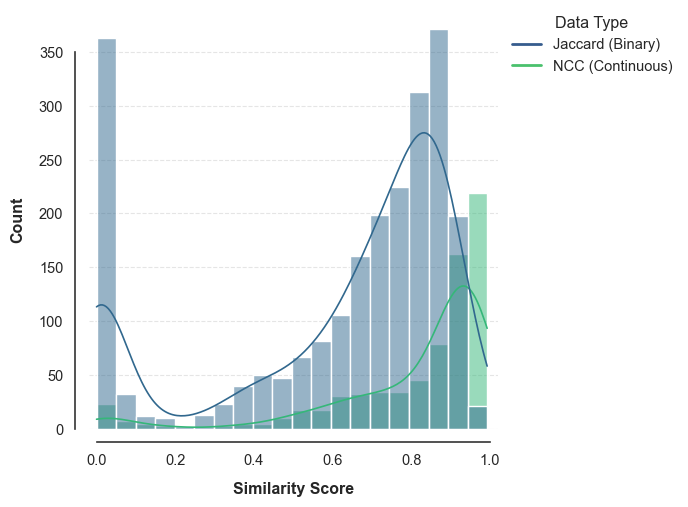

In [5]:
# Set professional base configuration
sns.set_theme(style="white", font="Arial", context="paper", font_scale=1.2)

# merge cont and binary dataframes for plotting
joined_df = pd.concat([df_binary.assign(data_type="Binary"),
                        df_continuous.assign(data_type="Continuous")], ignore_index=True, )

# 1. Plotting with explicit bin edges and a bounded KDE
g = sns.displot(
    data=joined_df,
    x='similarity_score',
    hue='data_type',
    kde=True,
    binwidth=0.05,          # Fixes deterministic bin intervals for reproducibility
    edgecolor='white',       # Adds a crisp boundary between histogram bars
    linewidth=1,
    palette="viridis",         # A solid, formal corporate/academic blue
    legend=False,            # Suppress legend in displot to create a custom one later
    kde_kws={'clip': (0.0, 1.0)} # Truncates the KDE curve strictly between 0 and 1
)

ax = g.ax

# 2. Clean up axes text (No top title!)
ax.set_xlabel("Similarity Score", fontweight='bold', labelpad=10)
ax.set_ylabel("Count", fontweight='bold', labelpad=10)

# Set precise limits matching the logical boundaries of the data
ax.set_xlim(-0.02, 1.02) 

# 3. Fine-tune lines, spines, and contrast
sns.despine(ax=ax, offset=10, trim=True)

# Make the axes spines darker and slightly more prominent for formal printing
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#333333')
    ax.spines[spine].set_linewidth(1.2)

# 4. Add subtle horizontal reference lines for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#cccccc')
ax.set_axisbelow(True) # Ensures grid lines sit behind the bars, not over them

handles = [
    plt.Line2D([], [], color=sns.color_palette("viridis")[1], lw=2, label="Jaccard (Binary)"),
    plt.Line2D([], [], color=sns.color_palette("viridis")[4], lw=2, label="NCC (Continuous)")
]
plt.legend(
    handles=handles,
    title="Data Type", 
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0,
    frameon=True,
    facecolor='white',
    edgecolor='none'
)

plt.savefig("../Results/similarity_scores_distribution.jpeg", dpi=300, bbox_inches='tight')
plt.savefig("../Results/similarity_scores_distribution.tiff", dpi=300, bbox_inches='tight')
plt.savefig("../Results/similarity_scores_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
binary_scores = joined_df[joined_df['data_type'] == 'Binary']['similarity_score'].values
continuous_scores = joined_df[joined_df['data_type'] == 'Continuous']['similarity_score'].values


In [40]:
[pg.normality(binary_scores), pg.normality(continuous_scores)]

[          W          pval  normal
 0  0.802276  8.452558e-47   False,
           W          pval  normal
 0  0.718536  3.508927e-33   False]

### Create Tables for Results

In [32]:
df_binary_average = df_binary.groupby(['Model', 'dye'])['similarity_score'].mean().reset_index()
df_binary_average['standard_deviation'] = df_binary.groupby(['Model', 'dye'])['similarity_score'].std().reset_index()['similarity_score']

df_continuous_average = df_continuous.groupby(['Model', 'dye'])['similarity_score'].mean().reset_index()
df_continuous_average['standard_deviation'] = df_continuous.groupby(['Model', 'dye'])['similarity_score'].std().reset_index()['similarity_score']

In [35]:
def create_mean_std_table(df):
    # Create table with mean +- standard deviation for each model and dye combination
    df['mean_std'] = (
        df['similarity_score'].round(3).astype(str) + " ± " + 
        df['standard_deviation'].round(3).astype(str)
    )

    # Step 2: Pivot the table to reshape it 
    # Models become rows (Index), Dyes become columns, cells contain the combined string
    table_df = df.pivot(index='Model', columns='dye', values='mean_std')

    # Optional: Clean up index and column names for a publication layout
    table_df.index.name = 'Model'
    table_df.columns.name = 'Dye Type'
    
    return table_df

In [36]:
df_binary_average = create_mean_std_table(df_binary_average)
df_continuous_average = create_mean_std_table(df_continuous_average)

In [40]:
table_combined = pd.concat([df_binary_average, df_continuous_average])

In [46]:
# Generates a professional booktabs style LaTeX code snippet
print(table_combined.to_latex(index=True, column_format='lcccccc'))

\begin{tabular}{lcccccc}
\toprule
Dye Type & HT29-dapi & HT29-pi & Hs766T-dapi & Hs766T-pi & both-dapi & both-pi \\
Model &  &  &  &  &  &  \\
\midrule
Decision Tree Classifier & 0.799 ± 0.155 & 0.746 ± 0.17 & 0.833 ± 0.059 & 0.0 ± 0.0 & 0.783 ± 0.173 & 0.468 ± 0.387 \\
Logistic Regression & 0.778 ± 0.16 & 0.725 ± 0.161 & 0.822 ± 0.068 & 0.0 ± 0.0 & 0.711 ± 0.153 & 0.484 ± 0.36 \\
Otsu Equalize & 0.717 ± 0.156 & 0.719 ± 0.171 & 0.696 ± 0.038 & 0.019 ± 0.027 & 0.71 ± 0.131 & 0.498 ± 0.357 \\
UNet Binary & 0.73 ± 0.145 & 0.78 ± 0.15 & 0.88 ± 0.084 & 0.0 ± 0.0 & 0.8 ± 0.134 & 0.513 ± 0.347 \\
Water Means & 0.747 ± 0.178 & 0.734 ± 0.207 & 0.686 ± 0.217 & 0.019 ± 0.031 & 0.72 ± 0.188 & 0.502 ± 0.37 \\
Watershed & 0.562 ± 0.197 & 0.626 ± 0.206 & 0.806 ± 0.211 & 0.016 ± 0.023 & 0.639 ± 0.23 & 0.43 ± 0.33 \\
Decision Tree Regressor & 0.901 ± 0.145 & 0.873 ± 0.12 & 0.924 ± 0.047 & 0.598 ± 0.11 & 0.911 ± 0.118 & 0.78 ± 0.17 \\
UNet Regressor & 0.882 ± 0.12 & 0.861 ± 0.115 & 0.954 ± 0.026 & 0.694